# 2D偏置采样轨迹生成实验

本实验演示了如何使用VPSTO框架中的VPTraj类生成具有偏置的随机轨迹。通过调整不同的参数（Q和P_prior），我们可以控制：

- **轨迹的随机性**：Q参数，对qT的精度矩阵，越大则到达位置和设定的越准确
- **对先验点的偏好**：P_prior参数控制轨迹向特定途径点偏移的强度，途经点的先验精度
- **轨迹的复杂度**：通过改变途径点数量来调整轨迹的平滑程度

## 实验设计

- **起点**：(0, 0) → **终点**：(1, 1)
- **先验途径点**：(0.1, 0.9) - 引导轨迹向左上方偏移
- **参数网格**：Q ∈ {0, 500, 1000000}, P ∈ {0, 500, 1000000}
- **轨迹数量**：每种参数组合生成1000条轨迹

In [1]:
# 导入必要的库
import numpy as np                    # 数值计算库
from vpsto.obf import OBF             # 椭球基函数（Optimal Basis Functions）
from vpsto.vptraj import VPTraj       # 途径点轨迹生成器

import matplotlib.pyplot as plt       # 绘图库

# Jupyter notebook魔法命令，用于自动重新加载模块
%load_ext autoreload
%autoreload 2

In [ ]:
# 定义轨迹的起始和终止条件
q0 = np.array([0, 0])    # 起始位置：原点 (0, 0)
qf = np.array([1, 1])    # 终止位置：目标点 (1, 1)
dq0 = np.array([0, 0])   # 起始速度：静止状态
dqf = np.array([0, 0])   # 终止速度：静止状态

# 噪声参数
R = 2e-1                 # 随时间加速度的惩罚矩阵

# 先验途径点位置（偏置采样的中心点）
via_prior = np.array([0.1, 0.9])  # 偏向于经过点 (0.1, 0.9)

# 采样轨迹数量
N_traj = 1000           # 每种参数组合下生成的轨迹数量

# 创建Q值（过程噪声）和P_prior值（先验精度）的网格
# 这些参数控制轨迹的随机性和对先验途径点的偏好强度
Qs = np.array([0, 5e2, 1e6])      # Q值：0（确定性）→ 高值（随机性强）
Ps = np.array([0, 5e2, 1e6])      # P值：0（无偏置）→ 高值（强偏置向先验点）

### 实验1：途径点数量 N_via = 2 的轨迹采样
对每种Q和P_prior参数组合生成轨迹样本，研究参数对轨迹形状和分布的影响。

In [3]:
# 实验1：使用较少的途径点
N_via = 2  # 途径点数量：2个中间控制点

# 创建轨迹生成器实例
vptraj = VPTraj(
    ndof=2,        # 自由度数量：2D平面运动
    N_eval=100,    # 轨迹评估点数：用于轨迹离散化的点数
    N_via=2,       # 途径点数量：轨迹中间的控制点数
    vel_lim=1,     # 速度限制：最大允许速度
    acc_lim=10     # 加速度限制：最大允许加速度
)

In [ ]:
# 存储不同参数组合下的轨迹和执行时间
Q_list = []  # 存储所有轨迹数据
T_list = []  # 存储对应的执行时间

# 设置先验途径点的均值向量
p_prior = np.zeros(2*N_via)  # 初始化为零向量（2*N_via维度）
idx_mid = N_via//2-1         # 计算中间途径点的索引
# 在中间途径点位置设置先验均值
p_prior[idx_mid*2:(idx_mid+1)*2] = via_prior

# 遍历所有Q和P参数组合
for Q in Qs:
    for P in Ps:
        # 设置先验协方差矩阵P_prior
        P_prior = np.zeros((2*N_via, 2*N_via))  # 初始化为零矩阵
        # 在中间途径点对应的位置设置先验精度
        P_prior[idx_mid*2:(idx_mid+1)*2, idx_mid*2:(idx_mid+1)*2] = P * np.eye(2)
        
        # 生成轨迹样本
        # q: 轨迹位置数据 [N_traj x N_eval x ndof]
        # T: 每条轨迹的执行时间 [N_traj]
        q, _, _, _, T = vptraj.sample_trajectories(
            N_traj,              # 采样轨迹数量
            q0,                  # 起始位置
            dq0=dq0,            # 起始速度
            qT=qf,              # 终止位置
            dqT=dqf,            # 终止速度
            Q=Q,                # 过程噪声参数（控制随机性）
            R=R,                # 随时间加速度的惩罚矩阵
            mu_prior=p_prior,   # 先验途径点均值
            P_prior=P_prior     # 先验途径点精度矩阵
        )
        
        Q_list.append(q)  # 保存轨迹数据
        T_list.append(T)  # 保存执行时间

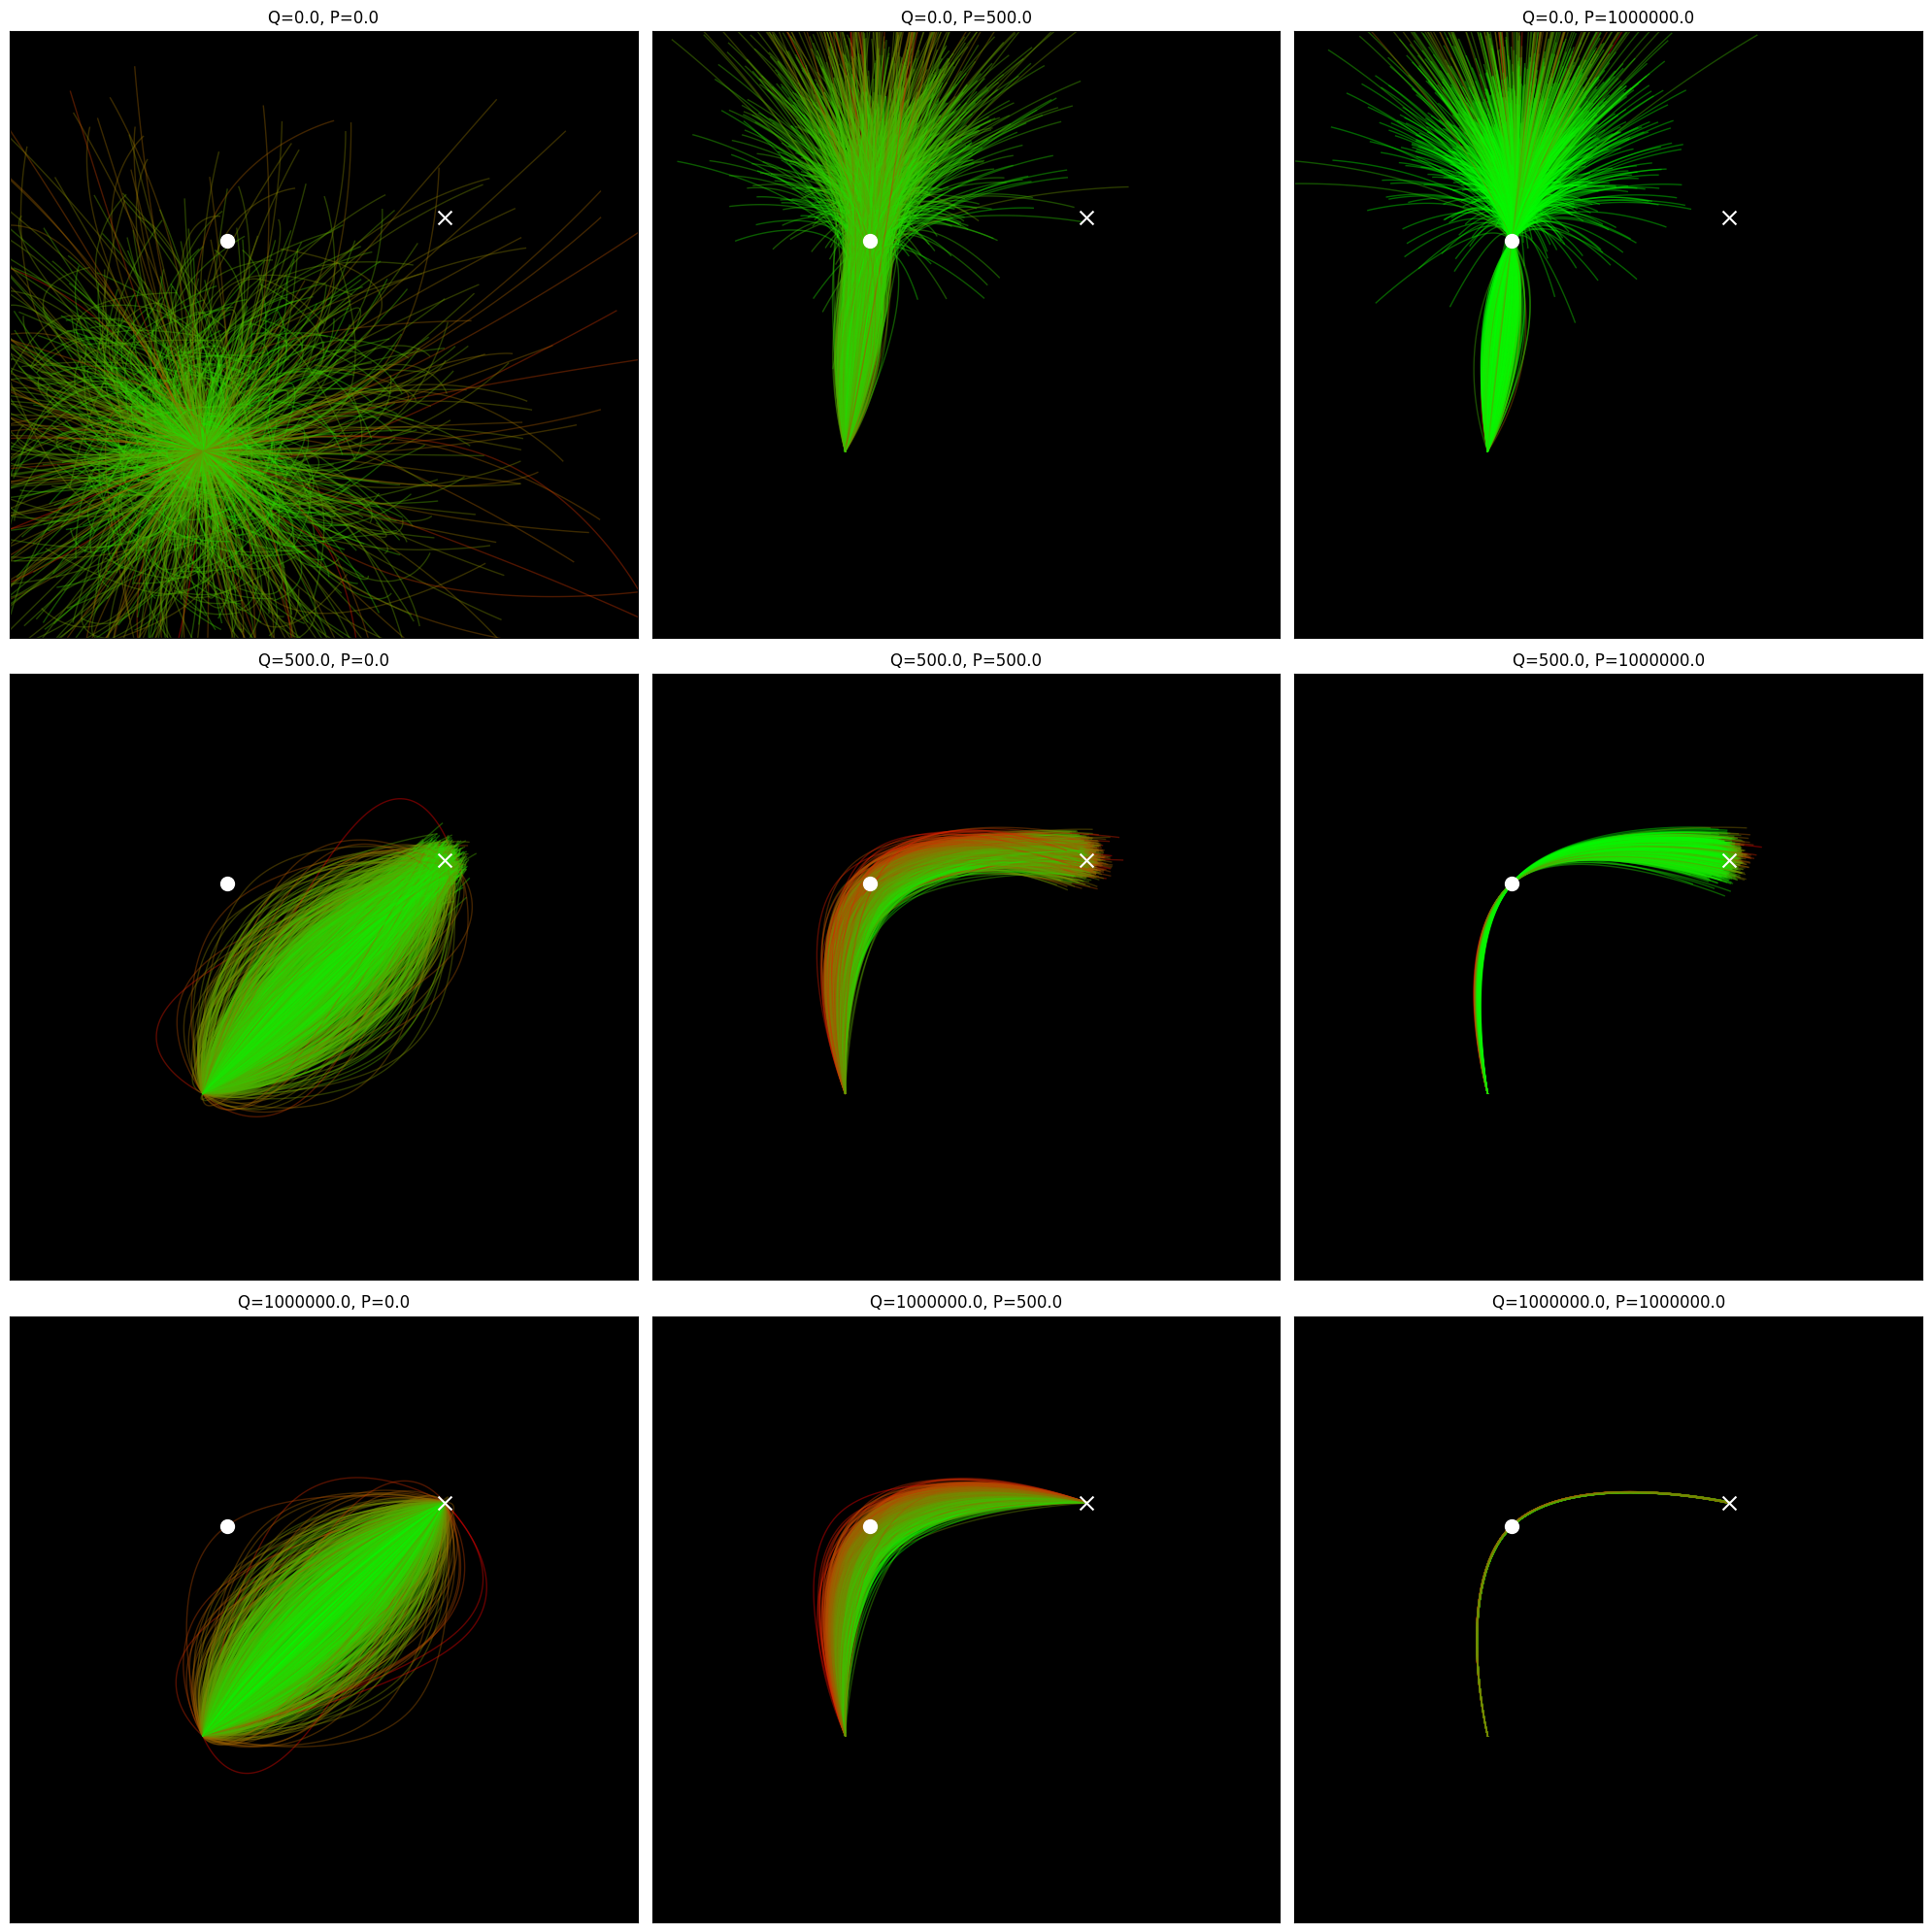

In [5]:
# 创建3x3子图网格来显示不同参数组合的结果
num_rows = 3
fig, axs = plt.subplots(num_rows, num_rows, figsize=(20,20))

# 设置黑色背景以便更好地显示彩色轨迹
for ax in axs.flat:
    ax.set_facecolor('k')

# 遍历所有参数组合并绘制对应的轨迹
for i in range(num_rows):
    for j in range(num_rows):
        idx = i*num_rows + j  # 计算当前参数组合的索引
        q = Q_list[idx]       # 获取对应的轨迹数据
        T = T_list[idx]       # 获取对应的执行时间
        
        # 计算基于执行时间的奖励值（时间越短，奖励越高）
        # 将执行时间归一化到[0,1]范围，然后转换为奖励
        rewards = 1 - (T - np.min(T)) / (np.max(T) - np.min(T))
        
        # 绘制所有轨迹
        for n in range(N_traj):
            # 根据奖励值设置颜色：红色（慢）→ 绿色（快）
            c = (1-rewards[n], rewards[n], 0)  # RGB颜色元组
            axs[i,j].plot(q[n,:,0], q[n,:,1], color=c, lw=1, alpha=.4)
        
        # 标记重要位置点
        axs[i,j].scatter(qf[0], qf[1], color='w', marker='x', s=100, zorder=10)      # 白色X：目标点
        axs[i,j].scatter(via_prior[0], via_prior[1], color='w', marker='o', s=100, zorder=10)  # 白色圆：先验途径点
        
        # 设置子图标题和属性
        axs[i,j].set_title(f"Q={Qs[i]}, P={Ps[j]}")  # 显示当前参数值
        axs[i,j].set_xlim([-.8,1.8])    # X轴范围
        axs[i,j].set_ylim([-.8,1.8])    # Y轴范围
        axs[i,j].set_xticks([])         # 隐藏X轴刻度
        axs[i,j].set_yticks([])         # 隐藏Y轴刻度

plt.tight_layout()  # 自动调整子图布局

### 实验2：途径点数量 N_via = 20 的轨迹采样
使用更多途径点研究轨迹的复杂性和平滑性变化。

In [6]:
# 实验2：使用更多的途径点
N_via = 20  # 增加途径点数量到20个，允许生成更复杂和平滑的轨迹

# 重新创建轨迹生成器实例（使用新的途径点数量）
vptraj = VPTraj(
    ndof=2,        # 自由度数量：2D平面运动
    N_eval=100,    # 轨迹评估点数：保持不变
    N_via=N_via,   # 途径点数量：现在是20个
    vel_lim=1,     # 速度限制：保持不变
    acc_lim=10     # 加速度限制：保持不变
)

In [7]:
# 重新初始化存储列表（为第二个实验）
Q_list = []  # 存储20途径点情况下的轨迹数据
T_list = []  # 存储对应的执行时间

# 重新设置先验途径点参数（适应新的途径点数量）
p_prior = np.zeros(2*N_via)  # 现在是40维向量（20个途径点 × 2维坐标）
idx_mid = N_via//2-1         # 重新计算中间途径点索引（第9个途径点）
# 在中间途径点位置设置先验均值
p_prior[idx_mid*2:(idx_mid+1)*2] = via_prior

# 遍历所有Q和P参数组合（与实验1相同的参数网格）
for Q in Qs:
    for P in Ps:
        # 设置先验协方差矩阵P_prior（现在是40×40的矩阵）
        P_prior = np.zeros((2*N_via, 2*N_via))  # 初始化为零矩阵
        # 只在中间途径点对应的位置设置先验精度
        P_prior[idx_mid*2:(idx_mid+1)*2, idx_mid*2:(idx_mid+1)*2] = P * np.eye(2)
        
        # 生成轨迹样本（与实验1相同的采样方法）
        q, _, _, _, T = vptraj.sample_trajectories(
            N_traj,              # 采样轨迹数量：保持1000条
            q0,                  # 起始位置
            dq0=dq0,            # 起始速度
            qT=qf,              # 终止位置
            dqT=dqf,            # 终止速度
            Q=Q,                # 过程噪声参数
            R=R,                # 观测噪声参数
            mu_prior=p_prior,   # 先验途径点均值（40维）
            P_prior=P_prior     # 先验途径点精度矩阵（40×40）
        )
        
        Q_list.append(q)  # 保存轨迹数据
        T_list.append(T)  # 保存执行时间

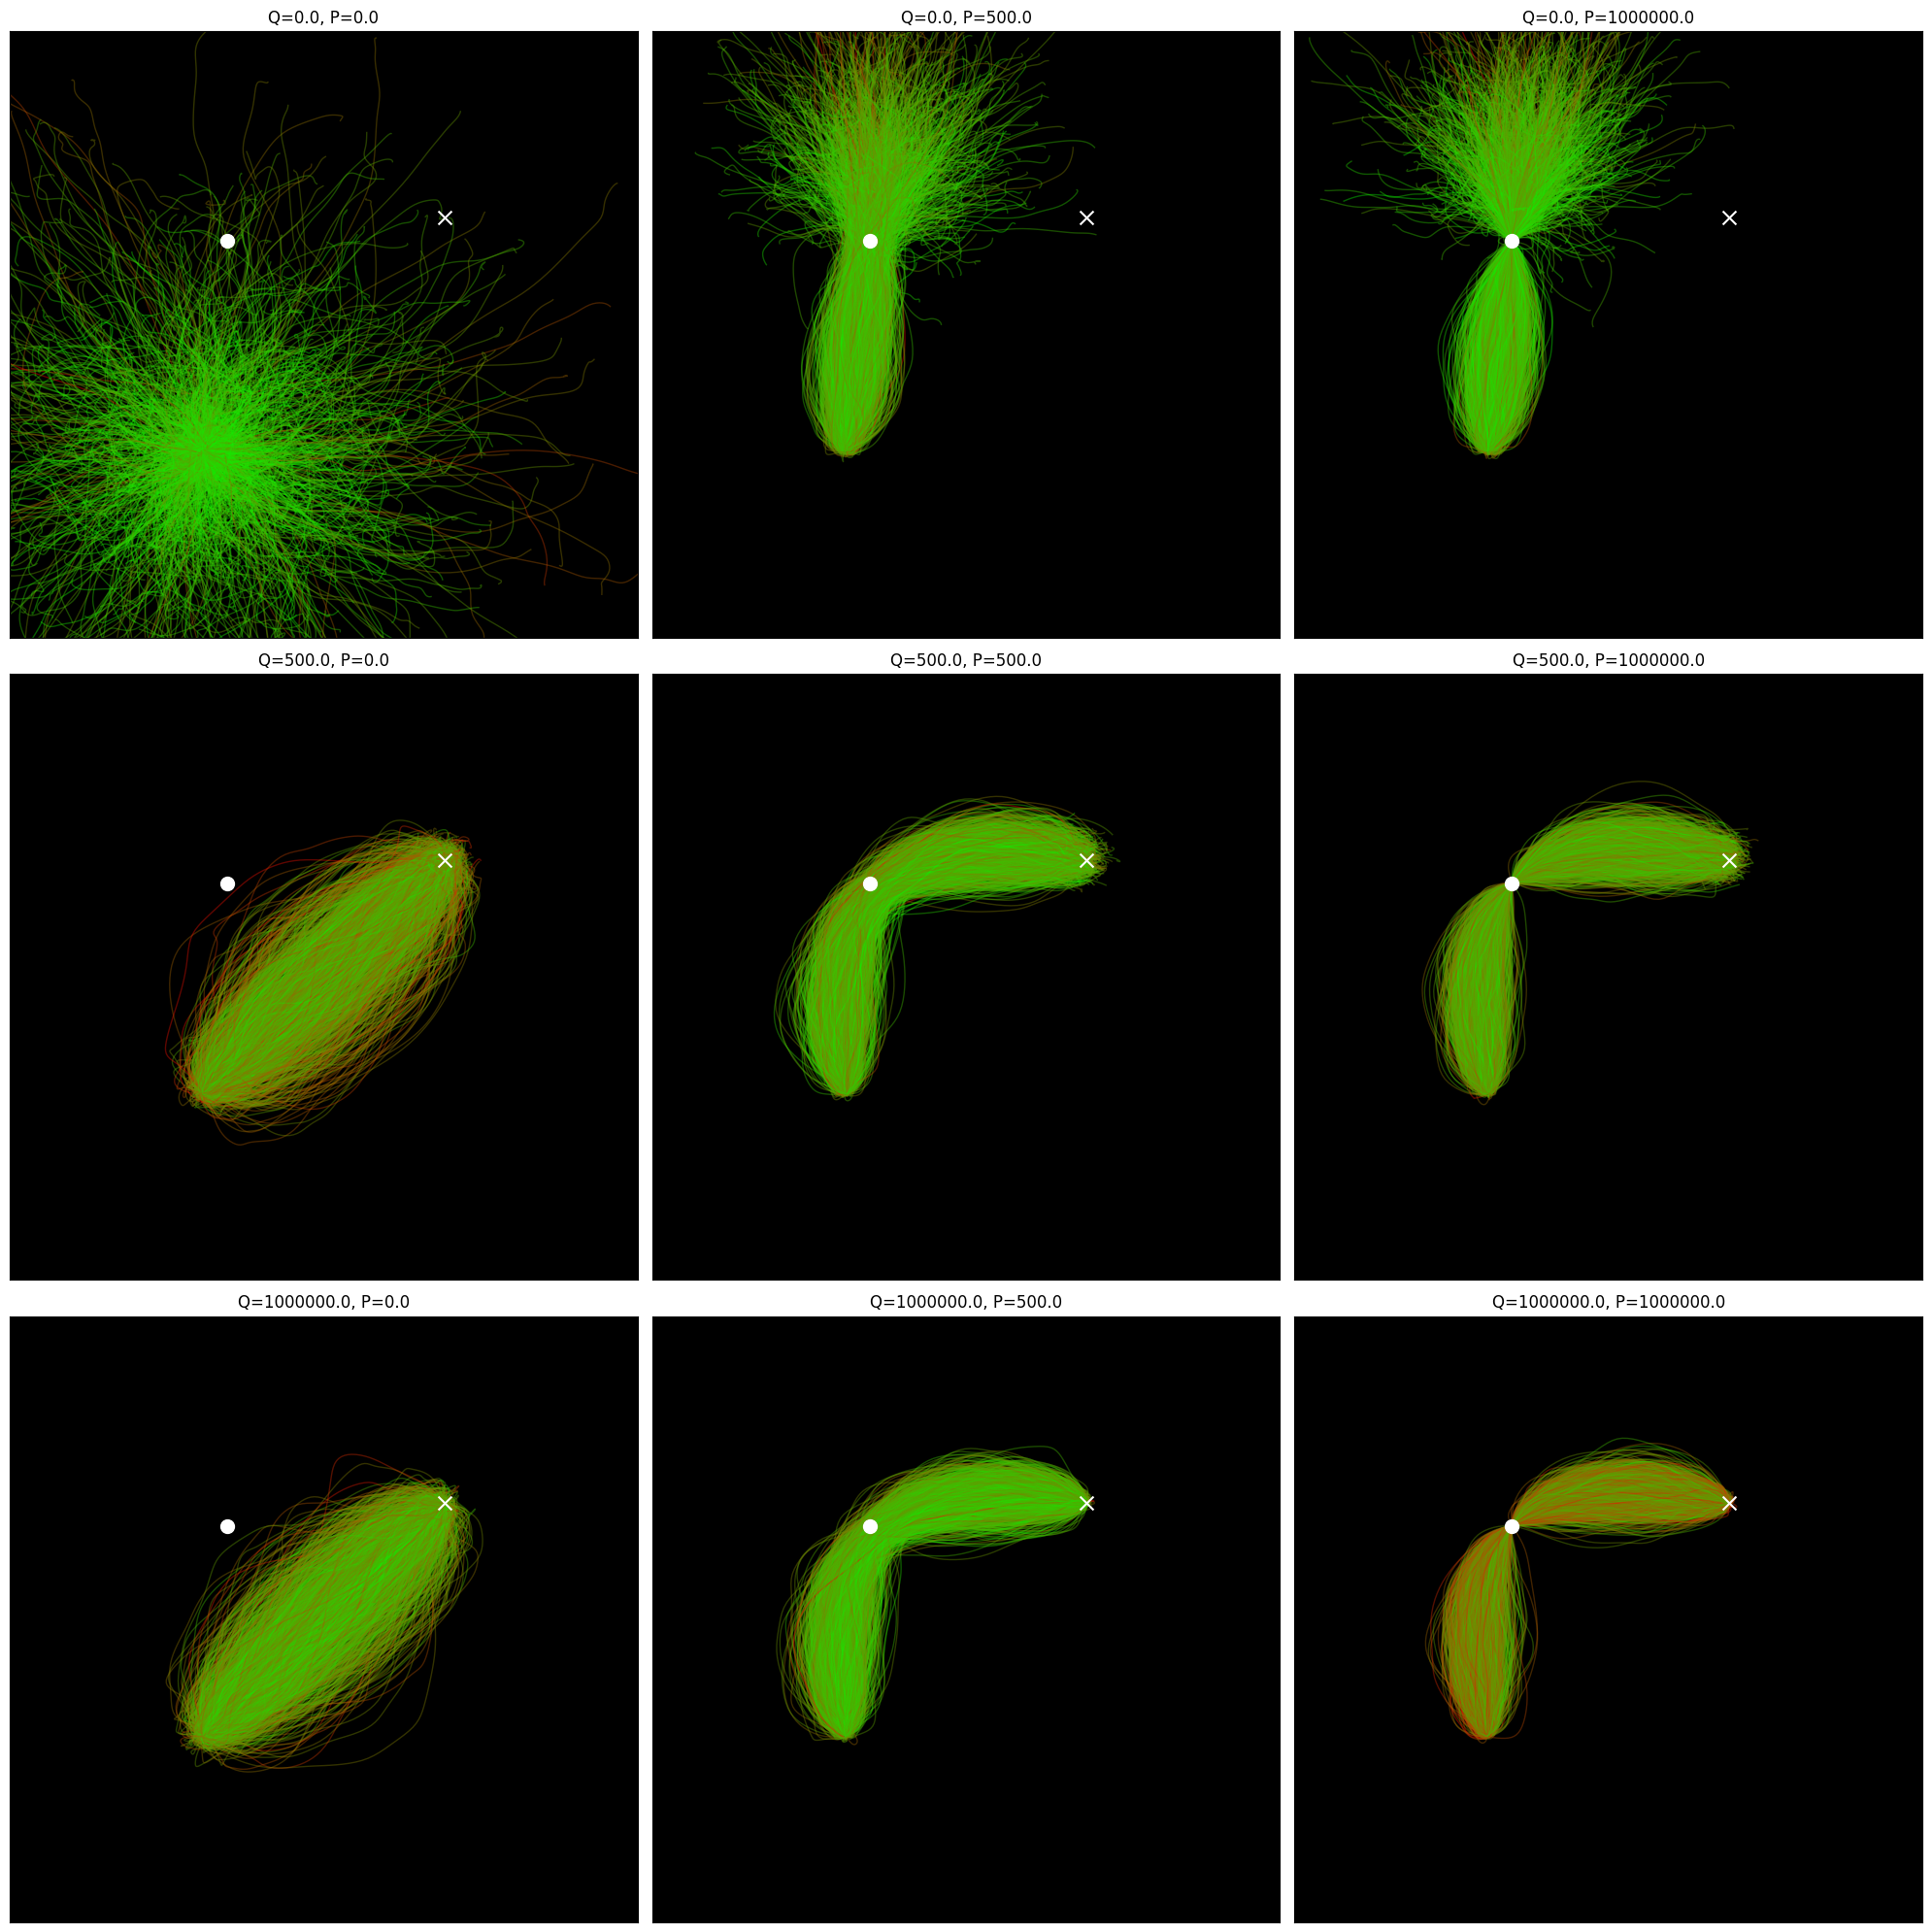

In [8]:
# 创建第二个3x3子图网格（20途径点实验结果）
num_rows = 3
fig, axs = plt.subplots(num_rows, num_rows, figsize=(20,20))

# 设置黑色背景以便更好地显示彩色轨迹
for ax in axs.flat:
    ax.set_facecolor('k')

# 遍历所有参数组合并绘制对应的轨迹（与实验1相同的可视化方法）
for i in range(num_rows):
    for j in range(num_rows):
        idx = i*num_rows + j  # 计算当前参数组合的索引
        q = Q_list[idx]       # 获取20途径点情况下的轨迹数据
        T = T_list[idx]       # 获取对应的执行时间
        
        # 计算基于执行时间的奖励值（时间越短，奖励越高）
        rewards = 1 - (T - np.min(T)) / (np.max(T) - np.min(T))
        
        # 绘制所有轨迹（预期会更平滑，因为有更多途径点）
        for n in range(N_traj):
            # 根据奖励值设置颜色：红色（慢）→ 绿色（快）
            c = (1-rewards[n], rewards[n], 0)  # RGB颜色元组
            axs[i,j].plot(q[n,:,0], q[n,:,1], color=c, lw=1, alpha=.4)
        
        # 标记重要位置点
        axs[i,j].scatter(qf[0], qf[1], color='w', marker='x', s=100, zorder=10)      # 白色X：目标点
        axs[i,j].scatter(via_prior[0], via_prior[1], color='w', marker='o', s=100, zorder=10)  # 白色圆：先验途径点
        
        # 设置子图标题和属性
        axs[i,j].set_title(f"Q={Qs[i]}, P={Ps[j]}")  # 显示当前参数值
        axs[i,j].set_xlim([-.8,1.8])    # X轴范围
        axs[i,j].set_ylim([-.8,1.8])    # Y轴范围
        axs[i,j].set_xticks([])         # 隐藏X轴刻度
        axs[i,j].set_yticks([])         # 隐藏Y轴刻度
        
plt.tight_layout()  # 自动调整子图布局

## 实验结果分析

### 参数效果说明

#### Q参数（最终精度）的影响：
- **Q = 0**：最终不到达给定终点
- **Q = 500**：最终基本到达给定终点
- **Q = 1,000,000**：最终基本到达给定终点

#### P参数（先验精度）的影响：
- **P = 0**：无偏置，轨迹不受先验途径点影响
- **P = 500**：中等偏置，轨迹倾向于经过先验点(0.1, 0.9)
- **P = 1,000,000**：强偏置，轨迹强制经过或接近先验点

#### 途径点数量的影响：
- **N_via = 2**：轨迹相对简单，转折较少
- **N_via = 20**：轨迹更加平滑，可以生成复杂的曲线形状

### 颜色编码含义：
- **绿色轨迹**：执行时间短，效率高
- **红色轨迹**：执行时间长，路径曲折
- **黄色轨迹**：中等执行时间

### 应用场景：
这种偏置采样方法特别适用于：
- 机器人路径规划中的偏好路径生成
- 避障轨迹中的安全区域偏置
- 人机协作中的舒适性轨迹生成